# Nashgrad example use

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from nashgrad.base import Value
from nashgrad.nn import Neuron, Layer, MLP

In [3]:
np.random.seed(1337)
random.seed(1337)


In [4]:
# sklearn examples: https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html

dir(Value)

['__add__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__pow__',
 '__radd__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmul__',
 '__rsub__',
 '__rtruediv__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__sub__',
 '__subclasshook__',
 '__truediv__',
 '__weakref__',
 'backward',
 'exp',
 'relu',
 'tanh']

In [5]:
# make up a dataset

from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

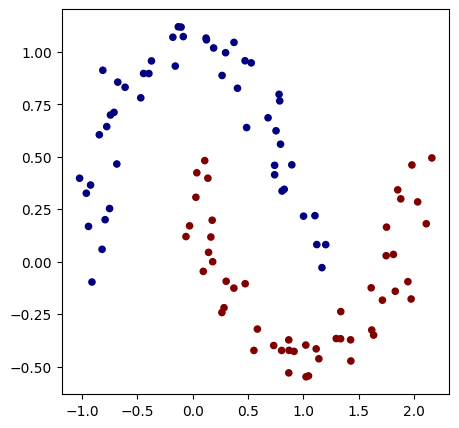

In [6]:

y = y*2 - 1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [7]:
# initialize a model 
model = MLP(2, [16, 16, 1]) # 2-layer neural network
#print(model)
print("number of parameters", len(model.parameters()))

MLP size list: [2, 16, 16, 1]
number of parameters 337


In [8]:
def loss(X, y, model):
    # Add batching stuff here later.
    Xb, yb = X, y
    
    scores = list(map(model, X))
    losses = [(1 + -yi*scorei).relu() for yi, scorei in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    # L2 regularization
    alpha = 1e-4
    reg_loss = alpha * sum((p*p for p in model.parameters()))
    total_loss = data_loss + reg_loss
    
    # also get accuracy
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)


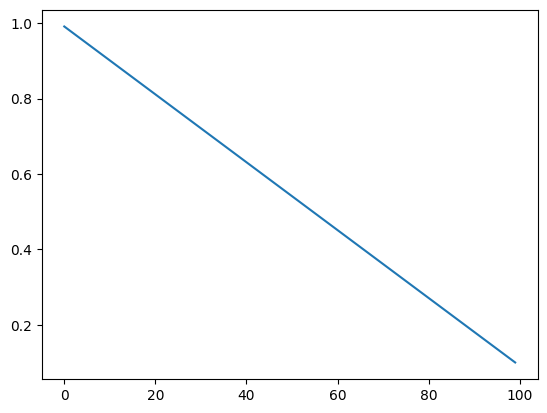

In [9]:
plt.plot(list(range(100)), [1.0 - 0.009*x for x in range(1, 101, 1)])

In [10]:
for k in range(100):
    total_loss, acc = loss(X, y, model)
    model.zero_grad()
    total_loss.backward()

    # update (sgd)
    learning_rate = 1.0 - 0.9*k/100
    for p in model.parameters():
        p.data -= learning_rate * p.grad
    
    if k % 1 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")
    

step 0 loss 0.7840043023159259, accuracy 68.0%
step 1 loss 0.5346887893624206, accuracy 73.0%
step 2 loss 0.40486112398826374, accuracy 83.0%
step 3 loss 0.3380828095624803, accuracy 86.0%
step 4 loss 0.2942618979033042, accuracy 88.0%
step 5 loss 0.2713707188453524, accuracy 90.0%
step 6 loss 0.2557758037037018, accuracy 90.0%
step 7 loss 0.24353269446140008, accuracy 91.0%
step 8 loss 0.2331166633588175, accuracy 91.0%
step 9 loss 0.22371429713875027, accuracy 91.0%
step 10 loss 0.21478840620418216, accuracy 91.0%
step 11 loss 0.20603142190103874, accuracy 91.0%
step 12 loss 0.1972226427758724, accuracy 92.0%
step 13 loss 0.18824544635214924, accuracy 93.0%
step 14 loss 0.17902966856680746, accuracy 94.0%
step 15 loss 0.1696750054539221, accuracy 94.0%
step 16 loss 0.1603343984865978, accuracy 94.0%
step 17 loss 0.15200986278726372, accuracy 96.0%
step 18 loss 0.1455087642655153, accuracy 96.0%
step 19 loss 0.15276142639895773, accuracy 95.0%
step 20 loss 0.14406510423987684, accurac

In [18]:
# no zero grad
model2 = MLP(2, [16, 16, 1]) # 2-layer neural network
learning_rate = 1.0
for k in range(20):
    total_loss, acc = loss(X, y, model2)
    model2.zero_grad()
    total_loss.backward()

    # update (sgd)
    #learning_rate = 0.5 - 0.9*k/100
    learning_rate = learning_rate / (1 + 0.01 * k)
    for p in model2.parameters():
        p.data -= learning_rate * p.grad
    
    if k % 1 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%, lr={learning_rate}")

MLP size list: [2, 16, 16, 1]
step 0 loss 0.9737838273895436, accuracy 50.0%, lr=1.0
step 1 loss 0.3205964503770614, accuracy 85.0%, lr=0.9900990099009901
step 2 loss 0.2715697791731845, accuracy 86.0%, lr=0.9706853038245
step 3 loss 0.2359288364668809, accuracy 89.0%, lr=0.942412916334466
step 4 loss 0.21991268488468993, accuracy 91.0%, lr=0.9061662657062173
step 5 loss 0.21030253749591116, accuracy 91.0%, lr=0.8630154911487783
step 6 loss 0.2024667664017663, accuracy 91.0%, lr=0.8141655576875266
step 7 loss 0.19568702467299892, accuracy 91.0%, lr=0.7609023903621743
step 8 loss 0.1892864580424676, accuracy 92.0%, lr=0.7045392503353466
step 9 loss 0.18309292367869842, accuracy 93.0%, lr=0.6463662847113271
step 10 loss 0.17703602242652441, accuracy 94.0%, lr=0.5876057133739336
step 11 loss 0.17110407946839457, accuracy 94.0%, lr=0.5293745165530933
step 12 loss 0.16533423138569706, accuracy 94.0%, lr=0.47265581835097614
step 13 loss 0.15981455709758036, accuracy 94.0%, lr=0.4182794852663